Equilibration completed for 40000 samples.
C(0) = 1.002370
<p0^2> = 1.002377  (theoretical: 1.0)
C(0)/C_max ratio: 1.000
Integrated correlation (conductivity): 1.0392e+00


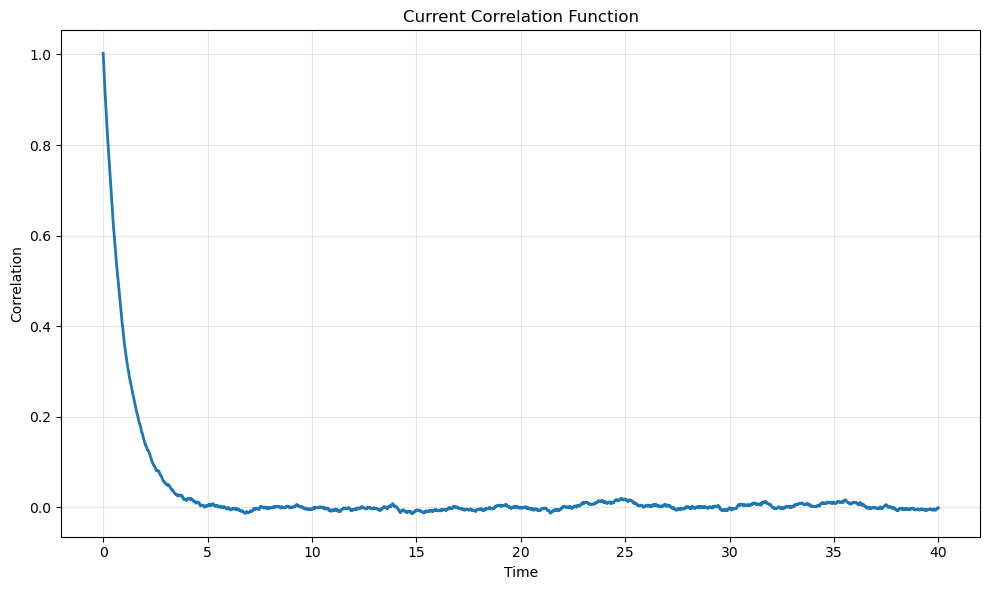

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from Langevin import LangevinSystem, PeriodicLangevinSystem
from correlation_func import time_evolution_correlation


def current_A(q, p):
    return  p  # J = 

def dHdq(q, p):
    return 0  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

# Energy and temperature in k_B*T scaling (dimensionless)
# k_B*T is the fundamental energy unit
k_B = 1.0  # Boltzmann constant (dimensionless in k_B*T scaling)
T = 1.0    # Temperature (dimensionless in k_B*T scaling)

# Physical parameters
gamma = 1  # Friction coefficient (scaled appropriately)
period = 2 * np.pi  # Period for periodic boundary conditions
dt = 0.01  # Time step (in appropriate units)

def sample_initial_conditions(num_samples):
    # In k_B*T scaling: standard deviation = sqrt(k_B*T) = 1
    q_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    print(f"Equilibration completed for {num_samples} samples.")
    return q_tempo, p_tempo

num_steps = 4000  # Number of steps to simulate
num_samples = 40000  # Number of samples for correlation
system = PeriodicLangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T, period=period)
q0, p0 = sample_initial_conditions(num_samples)  


j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)

# Debug: Check initial correlation value and statistics
C0 = j_correlation[0]
p0_sq = np.mean(p0**2)
print(f"C(0) = {C0:.6f}")
print(f"<p0^2> = {p0_sq:.6f}  (theoretical: 1.0)")
print(f"C(0)/C_max ratio: {C0/np.max(np.abs(j_correlation)):.3f}")

# Apply time-dependent damping correction if needed

integrated_value = np.trapezoid(j_correlation, dx=dt)
print(f"Integrated correlation (conductivity): {integrated_value:.4e}")

times = np.arange(0, num_steps*dt, dt)
plt.figure(figsize=(10, 6))
plt.plot(times, j_correlation, linewidth=2)
plt.title('Current Correlation Function')
plt.xlabel('Time')
plt.ylabel('Correlation')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.show()

Equilibration completed for 40000 samples.
C(0) = 1.007836
<p0^2> = 1.007839  (theoretical: 1.0)
C(0)/C_max ratio: 1.000
Integrated correlation (conductivity): 9.0471e-03


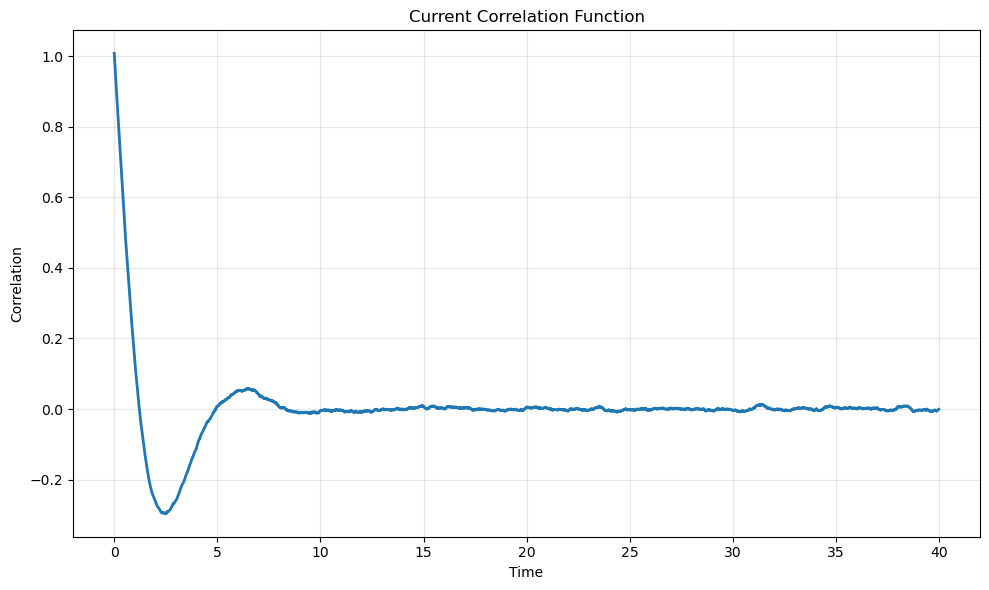

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from Langevin import LangevinSystem, PeriodicLangevinSystem
from correlation_func import time_evolution_correlation


def current_A(q, p):
    return  p  # J = 

def dHdq(q, p):
    return q  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

# Energy and temperature in k_B*T scaling (dimensionless)
# k_B*T is the fundamental energy unit
k_B = 1.0  # Boltzmann constant (dimensionless in k_B*T scaling)
T = 1.0    # Temperature (dimensionless in k_B*T scaling)

# Physical parameters
gamma = 1  # Friction coefficient (scaled appropriately)
period = 2 * np.pi  # Period for periodic boundary conditions
dt = 0.01  # Time step (in appropriate units)

def sample_initial_conditions(num_samples):
    # In k_B*T scaling: standard deviation = sqrt(k_B*T) = 1
    q_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    print(f"Equilibration completed for {num_samples} samples.")
    return q_tempo, p_tempo

num_steps = 4000  # Number of steps to simulate
num_samples = 40000  # Number of samples for correlation
system = LangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T)
q0, p0 = sample_initial_conditions(num_samples)  


j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)

# Debug: Check initial correlation value and statistics
C0 = j_correlation[0]
p0_sq = np.mean(p0**2)
print(f"C(0) = {C0:.6f}")
print(f"<p0^2> = {p0_sq:.6f}  (theoretical: 1.0)")
print(f"C(0)/C_max ratio: {C0/np.max(np.abs(j_correlation)):.3f}")

# Apply time-dependent damping correction if needed

integrated_value = np.trapezoid(j_correlation, dx=dt)
print(f"Integrated correlation (conductivity): {integrated_value:.4e}")

times = np.arange(0, num_steps*dt, dt)
plt.figure(figsize=(10, 6))
plt.plot(times, j_correlation, linewidth=2)
plt.title('Current Correlation Function')
plt.xlabel('Time')
plt.ylabel('Correlation')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.show()

Equilibration completed for 40000 samples.
C(0) = 0.993938
<p0^2> = 0.994016  (theoretical: 1.0)
C(0)/C_max ratio: 1.000
Integrated correlation (conductivity): 4.8499e-01


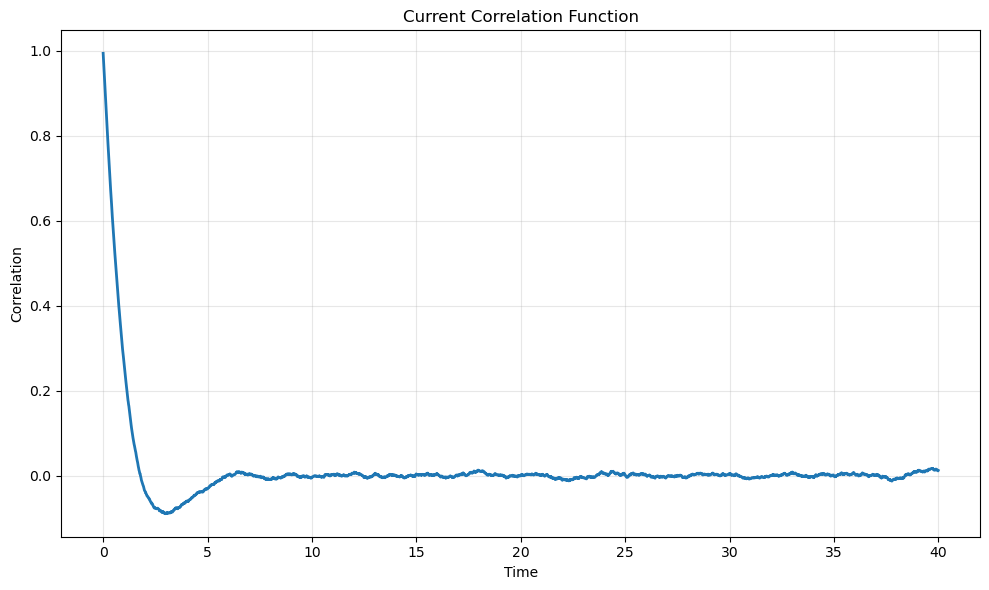

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from Langevin import LangevinSystem, PeriodicLangevinSystem
from correlation_func import time_evolution_correlation


def current_A(q, p):
    return  p  # J = 

def dHdq(q, p):
    return np.sin(q)  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

# Energy and temperature in k_B*T scaling (dimensionless)
# k_B*T is the fundamental energy unit
k_B = 1.0  # Boltzmann constant (dimensionless in k_B*T scaling)
T = 1.0    # Temperature (dimensionless in k_B*T scaling)

# Physical parameters
gamma = 1  # Friction coefficient (scaled appropriately)
period = 2 * np.pi  # Period for periodic boundary conditions
dt = 0.01  # Time step (in appropriate units)

def sample_initial_conditions(num_samples):
    # In k_B*T scaling: standard deviation = sqrt(k_B*T) = 1
    q_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    print(f"Equilibration completed for {num_samples} samples.")
    return q_tempo, p_tempo

num_steps = 4000  # Number of steps to simulate
num_samples = 40000  # Number of samples for correlation
system = PeriodicLangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T, period=period)
q0, p0 = sample_initial_conditions(num_samples)  


j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)

# Debug: Check initial correlation value and statistics
C0 = j_correlation[0]
p0_sq = np.mean(p0**2)
print(f"C(0) = {C0:.6f}")
print(f"<p0^2> = {p0_sq:.6f}  (theoretical: 1.0)")
print(f"C(0)/C_max ratio: {C0/np.max(np.abs(j_correlation)):.3f}")

# Apply time-dependent damping correction if needed

integrated_value = np.trapezoid(j_correlation, dx=dt)
print(f"Integrated correlation (conductivity): {integrated_value:.4e}")

times = np.arange(0, num_steps*dt, dt)
plt.figure(figsize=(10, 6))
plt.plot(times, j_correlation, linewidth=2)
plt.title('Current Correlation Function')
plt.xlabel('Time')
plt.ylabel('Correlation')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.show()

Equilibration completed for 40000 samples.
C(0) = 1.004847
<p0^2> = 1.004871  (theoretical: 1.0)
C(0)/C_max ratio: 1.000
Integrated correlation (conductivity): 5.3837e-01


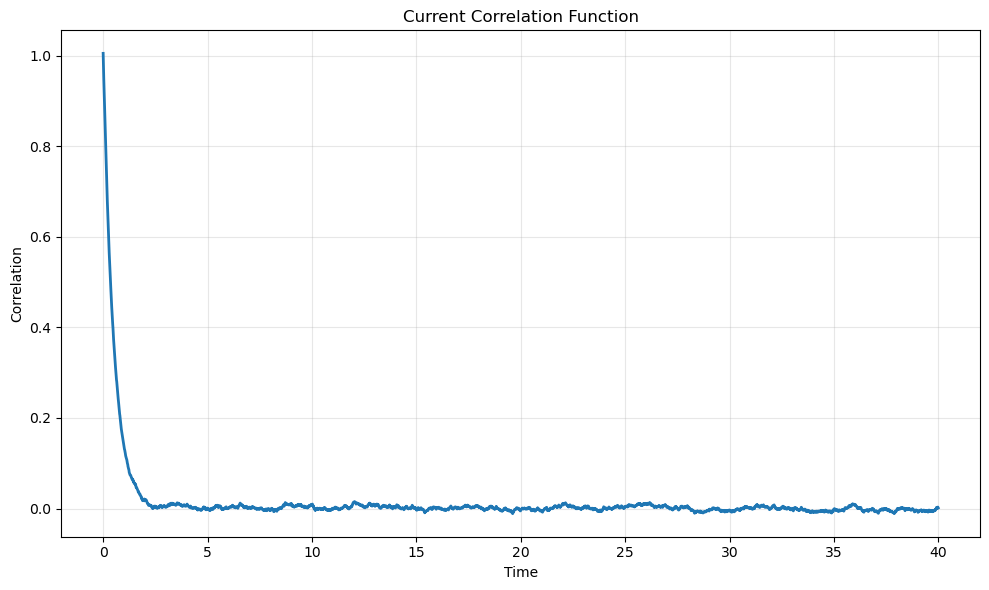

In [7]:
gamma = 2  # Friction coefficient (scaled appropriately)
def sample_initial_conditions(num_samples):
    # In k_B*T scaling: standard deviation = sqrt(k_B*T) = 1
    q_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    print(f"Equilibration completed for {num_samples} samples.")
    return q_tempo, p_tempo

num_steps = 4000  # Number of steps to simulate
num_samples = 40000  # Number of samples for correlation
system = PeriodicLangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T, period=period)
q0, p0 = sample_initial_conditions(num_samples) 

j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)

# Debug: Check initial correlation value and statistics
C0 = j_correlation[0]
p0_sq = np.mean(p0**2)
print(f"C(0) = {C0:.6f}")
print(f"<p0^2> = {p0_sq:.6f}  (theoretical: 1.0)")
print(f"C(0)/C_max ratio: {C0/np.max(np.abs(j_correlation)):.3f}")

# Apply time-dependent damping correction if needed

integrated_value = np.trapezoid(j_correlation, dx=dt)
print(f"Integrated correlation (conductivity): {integrated_value:.4e}")

times = np.arange(0, num_steps*dt, dt)
plt.figure(figsize=(10, 6))
plt.plot(times, j_correlation, linewidth=2)
plt.title('Current Correlation Function')
plt.xlabel('Time')
plt.ylabel('Correlation')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.show()

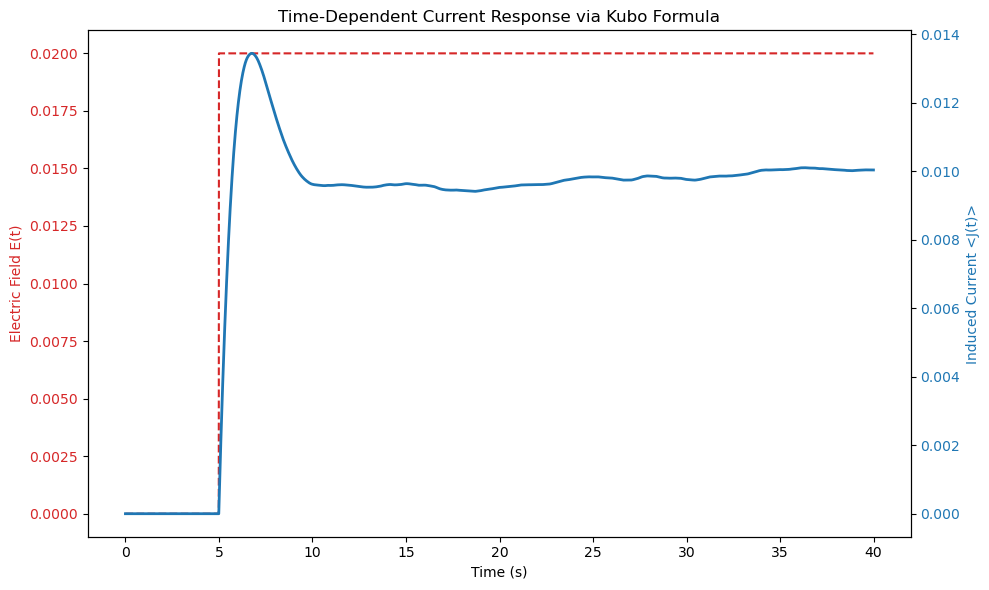

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from Langevin import LangevinSystem, PeriodicLangevinSystem
from correlation_func import time_evolution_correlation


def current_A(q, p):
    return  p  # J = p

def dHdq(q, p):
    return np.sin(q)  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

T = 1  # Temperature in Kelvin
k_B = 1  # Boltzmann constant in J/K
gamma = 1  # Friction coefficient
period = 2 * np.pi  # Period for periodic boundary conditions
dt = 0.01  # Time step in seconds

def sample_initial_conditions(num_samples):
    q_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    return q_tempo, p_tempo

def electric_field(t):
    if t < 5:
        return 0  # Constant electric field for t < 5s
    else:
        return 0.02 # Constant electric field for t >= 20s

num_steps = 4000  # Number of steps to simulate
num_samples = 40000  # Number of samples for correlation
system = PeriodicLangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T, period=period)
q0, p0 = sample_initial_conditions(num_samples)


j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)


# --- 2. タイムラインと電場 E(t) の配列を作成 ---
times = np.arange(0, num_steps * dt, dt)
E_t = np.array([electric_field(t) for t in times])

# --- 3. 久保公式に基づく応答関数 σ(t) の作成 ---
# 線形応答理論では、相関関数を k_B * T で割る必要があります
response_function = j_correlation / (k_B * T)

# --- 4. 畳み込み積分の実行 ---
# np.convolve で -inf から t までの積分を一括計算します
# dt を掛けることで、単なる配列の和ではなく「積分」になります
J_t = np.convolve(E_t, response_function, mode='full')[:num_steps] * dt 

# --- 5. プロット（原因である電場と、結果である電流を左右の軸で比較） ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左軸：電場 E(t) （赤の破線）
color = 'tab:red'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Electric Field E(t)', color=color)
ax1.plot(times, E_t, color=color, linestyle='--', label='Electric Field')
ax1.tick_params(axis='y', labelcolor=color)  # 電場のON/OFFを見やすくするための調整

# 右軸：電流応答 <J(t)> （青の実線）
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Induced Current <J(t)>', color=color)
ax2.plot(times, J_t, color=color, linewidth=2, label='Current Response')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Time-Dependent Current Response via Kubo Formula')
fig.tight_layout()
plt.show()

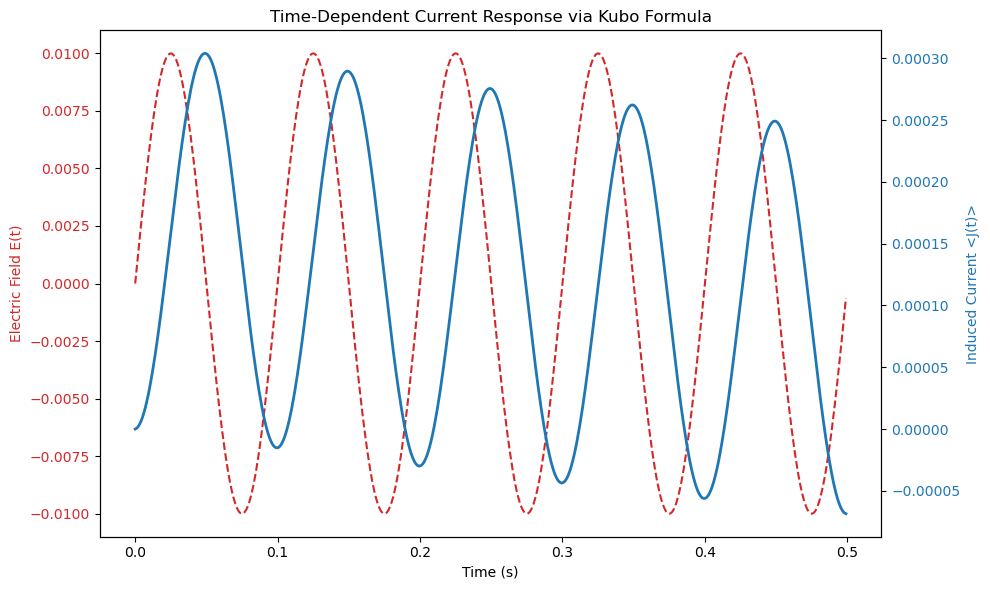

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from Langevin import LangevinSystem, PeriodicLangevinSystem
from correlation_func import time_evolution_correlation


def current_A(q, p):
    return  p  # J = p

def dHdq(q, p):
    return np.sin(q)  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

T = 1  # Temperature in Kelvin
k_B = 1  # Boltzmann constant in J/K
gamma = 1  # Friction coefficient
period = 2 * np.pi  # Period for periodic boundary conditions
dt = 0.001  # Time step in seconds

def sample_initial_conditions(num_samples):
    q_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    return q_tempo, p_tempo

def electric_field(t):
    return 0.01*np.sin(2 * np.pi * 10 * t)  # Example: sinusoidal electric field with frequency 10 Hz

num_steps = 500  # Number of steps to simulate
num_samples = 40000  # Number of samples for correlation
system = PeriodicLangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T, period=period)
q0, p0 = sample_initial_conditions(num_samples)


j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)


# --- 2. タイムラインと電場 E(t) の配列を作成 ---
times = np.arange(0, num_steps * dt, dt)
E_t = np.array([electric_field(t) for t in times])

# --- 3. 久保公式に基づく応答関数 σ(t) の作成 ---
# 線形応答理論では、相関関数を k_B * T で割る必要があります
response_function = j_correlation / (k_B * T)

# --- 4. 畳み込み積分の実行 ---
# np.convolve で -inf から t までの積分を一括計算します
# dt を掛けることで、単なる配列の和ではなく「積分」になります
J_t = np.convolve(E_t, response_function, mode='full')[:num_steps] * dt 

# --- 5. プロット（原因である電場と、結果である電流を左右の軸で比較） ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左軸：電場 E(t) （赤の破線）
color = 'tab:red'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Electric Field E(t)', color=color)
ax1.plot(times, E_t, color=color, linestyle='--', label='Electric Field')
ax1.tick_params(axis='y', labelcolor=color)  # 電場のON/OFFを見やすくするための調整

# 右軸：電流応答 <J(t)> （青の実線）
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Induced Current <J(t)>', color=color)
ax2.plot(times, J_t, color=color, linewidth=2, label='Current Response')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Time-Dependent Current Response via Kubo Formula')
fig.tight_layout()
plt.show()

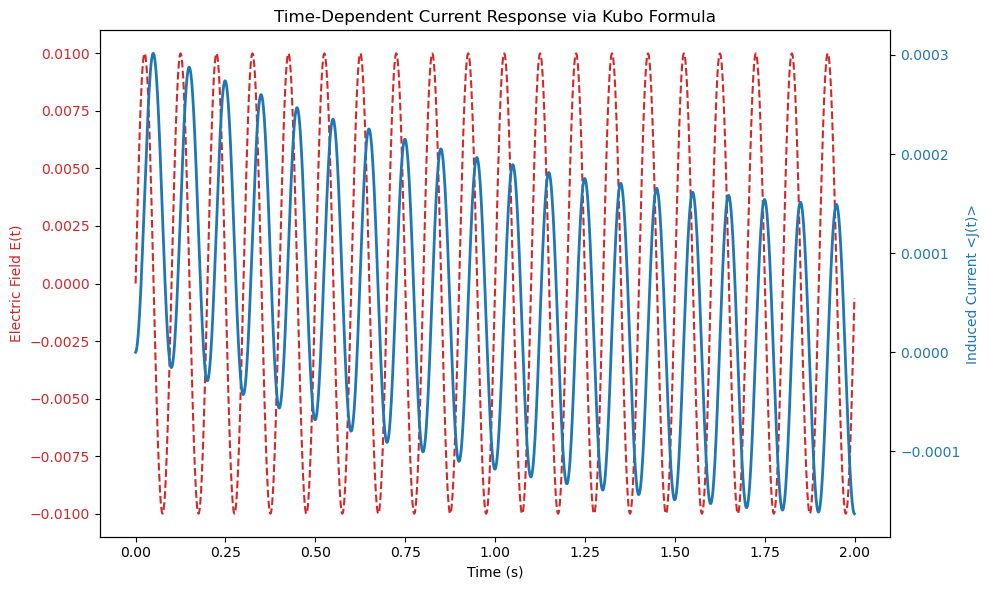

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from Langevin import LangevinSystem, PeriodicLangevinSystem
from correlation_func import time_evolution_correlation


def current_A(q, p):
    return  p  # J = p

def dHdq(q, p):
    return np.sin(q)  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

T = 1  # Temperature in Kelvin
k_B = 1  # Boltzmann constant in J/K
gamma = 1  # Friction coefficient
period = 2 * np.pi  # Period for periodic boundary conditions
dt = 0.001  # Time step in seconds

def sample_initial_conditions(num_samples):
    q_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    return q_tempo, p_tempo

def electric_field(t):
    return 0.01*np.sin(2 * np.pi * 10 * t)  # Example: sinusoidal electric field with frequency 10 Hz

num_steps = 2000  # Number of steps to simulate
num_samples = 20000  # Number of samples for correlation
system = PeriodicLangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T, period=period)
q0, p0 = sample_initial_conditions(num_samples)


j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)


# --- 2. タイムラインと電場 E(t) の配列を作成 ---
times = np.arange(0, num_steps * dt, dt)
E_t = np.array([electric_field(t) for t in times])

# --- 3. 久保公式に基づく応答関数 σ(t) の作成 ---
# 線形応答理論では、相関関数を k_B * T で割る必要があります
response_function = j_correlation / (k_B * T)

# --- 4. 畳み込み積分の実行 ---
# np.convolve で -inf から t までの積分を一括計算します
# dt を掛けることで、単なる配列の和ではなく「積分」になります
J_t = np.convolve(E_t, response_function, mode='full')[:num_steps] * dt 

# --- 5. プロット（原因である電場と、結果である電流を左右の軸で比較） ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左軸：電場 E(t) （赤の破線）
color = 'tab:red'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Electric Field E(t)', color=color)
ax1.plot(times, E_t, color=color, linestyle='--', label='Electric Field')
ax1.tick_params(axis='y', labelcolor=color)  # 電場のON/OFFを見やすくするための調整

# 右軸：電流応答 <J(t)> （青の実線）
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Induced Current <J(t)>', color=color)
ax2.plot(times, J_t, color=color, linewidth=2, label='Current Response')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Time-Dependent Current Response via Kubo Formula')
fig.tight_layout()
plt.show()